# SiReNetA basic examples – "Random Walk" canonical model
Authors: **Matthieu Gilson** and **Gorka Zamora-López**


This notebook is a quick introductory example for the use of the *SiReNetA* python package. For more detailed explanations and step-by-step tutorials on *Stimulus-Response Network Analysis*, please visit the [SiReNetA – Tutorials repository](https://github.com/mb-BCA/SiReNetA_Tutorials).

--------------------

### Dependencies

*sireneta* is built using *[xarray](https://docs.xarray.dev/en/stable/#)* in order to add labelled anotations and attributes to the underlying *numpy* arrays, which are relevant for the correct analysis of the response matrices. Running this notebook thus requires a Python (>3.6) installation together with:
- *xarray* (>=2026.01.0). Labelled array support.
- *numpy* (>=1.6). Fast array operations.
- *matplotlib*. For visualizations and plotting.
- *scipy*. Not used in the notebook, but dependency of *sireneta*.
- *sireneta*. Stimulus-response network analysis.


#### Import the main libraries


In [1]:
# Imports from Python's standard library
from timeit import default_timer as timer
# Third-party packages
import matplotlib.pyplot as plt
%matplotlib inline
import xarray as xr
import numpy as np
import sireneta as sna


#### Getting information

As usual, while working in interactive sessions, built-in `help()` or IPythons' `name?` shortcut will show further details of the modules and the functions. 

> NOTE: For now, importing *sireneta* does not bring the functions in the responses.py module into the namespace. Thus, generation of response tensor is called as, e.g., `>>> sna.responses.OrnsteinUhlenbeck(con, ...)`. All other functions are imported to the first hierarchical level: `sna.function()`.


In [ ]:
help(sna)

In [ ]:
#help(sna.metrics)
help(sna.responses)

In [ ]:
#sna.GlobalResponse?
#sna.NodeResponses?
#sna.responses.RandomWalk?
sna.responses.LeakyCascade?

## Overview of basic concepts

The aim of the present Stimulus-Response Network Analysis is to investigate the properties of networks based on how stimuli propagate along the network, for different canonical models. In this notebook we use the **Random Walk** which describes the ***discrete-time*** propagation of particles on a network. Given connectivity matrix $A$ (weighted or unweighted, directed or undirected) and transition probability $T$, the evolution of the system is given by

$$\mathbf{x}_t = T \, \mathbf{x}_{t-1}.$$

Here, $x_{i,t}$ is a column vector representing the expected number of walkers found at node $i$ at time $t$. Initial conditions $\mathbf{x}_0$ denote the number of walkers initially seeded at each node. We will denote this as the initial stimulus $\mathbf{s}_0$, or `S0`.
The model has no further parameters.


## 1. Load a connectivity matrix

The folder "./Data/" contains a few sample networks for these tests. Choose one

In [5]:
## LOAD A CONNECTIVITY MATRIX

## Small sample graphs
net = np.loadtxt('Data/testnet_N8_Directed.txt').T
#net = np.loadtxt('Data/testnet_N8_Undirected.txt').T
## Path graphs
#net = np.loadtxt('Data/testnet_PathGraph_N10.txt').T
#net = np.loadtxt('Data/testnet_PathDigraph_N10.txt').T
## Structural brain connectivity
#net = np.load('Data/testnet_SC.npy').T



> **ACHTUNG!** Notice that we included a `.T` at the end of the loading to transpose the adjacency matrices. The reason is that those networks were created following the graph convention (rows = outputs) but *sireneta* follows the dynamical systems convention (columns = outputs).
> - Graph theory convention $A_{ij} = 1$ means the link $i \to j$.
> - In dynamical systems $A_{ij} = 1$ means the link $i \gets j$.

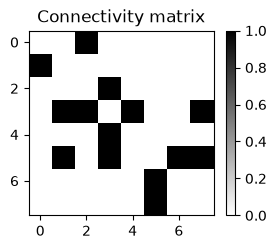

In [6]:
# Show the connectivity matrix
%matplotlib inline
plt.figure(figsize=(3.2,2.4))
plt.title( 'Connectivity matrix' )
plt.imshow(net, cmap='gray_r')
plt.colorbar();

## 2. Compute the response matrices

In this case, the model has no parameters but we first need to compute its transition probability matrix. Additionally, we need to define:
- Duration of the simulation.
- Initial conditions $\mathbf{s}_0$, as `S0vec`.

> **NOTE:** Initial conditions `S0vec` can be defined either as a number or a vector. A number will same initial conditions for all nodes while in a vector we can specify the number of particles seeded at each node.

In [7]:
# 1) Define the duration of the simulation
tfinal = 20

# 2) Define the stimulus amplitudes (initial conditions) as a vector
N = len(net) 
## All nodes start with one night walker
#S0vec = 1
## Define initial number of walkers arbitrarily
S0vec = np.zeros(N, dtype=np.float64)
S0vec[0] = 1
S0vec[1] = 3
S0vec[3] = 2
S0vec[5] = 1

# 3) Finally, compute the pair-wise response matrices (response tensor)
resp_tensor = sna.responses.RandomWalk(net, S0=S0vec, tmax=tfinal)


### Exploring the `resp_tensor`

The result `resptensor` is a `xarray.DataArray` object containing a 3D numpy `ndarray` and additional metadata. The three dimensions are called: `['time', 'nodes_to', 'nodes_from']`.

> `xarray` does not allow two dimensions to have the same name (to avoid confusion when using dimension names to slice the data). Therefore, the distinction between `'nodes_to'` and `'nodes_from'`.

Much like in *pandas*, each entry along the different dimensions has their own label. Here, we didn't provide labels but they were generated automatically:
- `'time'` : (0, 1, 2, …, tfinal-1), as an `np.array` of `uint64` dtype.
- `'nodes_to'` : \['node_0', 'node_2', 'node_3', … , 'node_(N-1)'\] as an `nd.array`.
- `'nodes_from'` : \['node_0', 'node_2', 'node_3', … , 'node_(N-1)'\] as an `nd.array`.

The time dimension always gets automatically generated depending on the duration and the time-step provided for the simulation. If labels for the nodes available, these can be passed to the response tensor generation functions via the optional parameter `labels`. 

*xarray* allows for various ways to explore the content of a DataArray. Here a few key commands:
- Typing `resp_tensor` will display all information.
- `resp_tensor.values` is the underlying numpy array.
- `resp_tensor.dims` shows the names of the dimensions.
- `resp_tensor['time']` shows the information regarding the 'time' dimension.
- `resp_tensor['nodes_to']` shows the information regarding the 'nodes_to' dimension.
- `resp_tensor['time'].values` is the numpy array of the labelled indices.


In [8]:
## Displaying information regarding the dimensions
resp_tensor['time']
#resp_tensor['nodes_to']
#resp_tensor['nodes_from']

<xarray.DataArray 'time' (time: 21)> Size: 168B
array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20], dtype=uint64)
Coordinates:
  * time     (time) uint64 168B 0 1 2 3 4 5 6 7 8 ... 12 13 14 15 16 17 18 19 20

In [9]:
## The underlying values
#resp_tensor['time'].values
resp_tensor['nodes_to'].values
#resp_tensor['nodes_from'].values

array(['node_0', 'node_1', 'node_2', 'node_3', 'node_4', 'node_5',
       'node_6', 'node_7'], dtype='<U6')

In [10]:
## The length of the dimensions
resp_tensor.sizes
#resp_tensor.sizes['time']
#resp_tensor.sizes['nodes_to']
#resp_tensor.sizes['nodes_from']

Frozen({'time': 21, 'nodes_to': 8, 'nodes_from': 8})

In [11]:
## Displaying general information
resp_tensor

<xarray.DataArray (time: 21, nodes_to: 8, nodes_from: 8)> Size: 11kB
array([[[1.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 3.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 1.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [1.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
...
        [0.32020499, 0.91826949, 0.        , ..., 0.32084756,
         0.        , 0.        ],
        [0.15165724, 0.48030748, 0.        , ..., 0.15188079,
         0.        , 0.        ],
        [0.15165724, 0.48030748, 0.        , ..., 0.15188079,
         0.        , 0.        ]],

       [[0.03159253, 0.09354168, 0.        , ..., 0.03328041,
         0.        , 0.        ],
        [0.03054133, 0.0947776 , 0.        , ..., 0.02843982,
         0.        , 0.        ],
        [0.06236112, 0.18684907, 0.        , ..., 0.05962038,
         0.        , 0.        ],
        ...,
        [0.30608983, 0.95312229, 0.        , ..., 0.30492571,
         0.        , 0.        ],
        [0.16010249, 0.45913475, 0.        , ..., 0.16042378,
         0.        , 0.        ],
        [0.16010249, 0.45913475, 0.        , ..., 0.16042378,
         0.        , 0.        ]]], shape=(21, 8, 8))
Coordinates:
  * time        (time) uint64 168B 0 1 2 3 4 5 6 7 8 ... 13 14 15 16 17 18 19 20
  * nodes_to    (nodes_to) <U6 192B 'node_0' 'node_1' ... 'node_6' 'node_7'
  * nodes_from  (nodes_from) <U6 192B 'node_0' 'node_1' ... 'node_6' 'node_7'
Attributes:
    model:       RandomWalk
    time_class:  discrete
    dt:          1.0
    S0:          [1. 3. 0. 2. 0. 1. 0. 0.]

### Special attributes

As seen in the data summary above, there is a list of attributes. These are not the default `xarray.DataArra` default, but user defined attributes. In this case `resp_tensor` was given the following:
- `'model'` : Underlying dynamical model.
- `'time_class'` : whether it is time-discrete or time-continuous model.
- `dt` : the time-step of the simulation.
- `S0` : the initial stimulus.

> **NOTE - 1:** These attributes are always present in all generated response results, but other specific parameters (e.g., model parameters) will also be included.

These user-defined attributes are stored as a dictionary in `xarr.attrs` and can be recalled or iterated as any other dictionary.

> **NOTE - 2:** The importance of these attributes is that, given that SiReNetA is meant to evaluate descriptors for different models, the functions to compute them have the necessary information to do the computations, e.g., the original `dt` is always known. Also, to assess whether a metric is (un)suitable and raise due warnings or errors, e.g., if some metric is only suitable for time-continuous but not for time-discrete models.

In [12]:
resp_tensor.attrs

{'model': 'RandomWalk',
 'time_class': 'discrete',
 'dt': 1.0,
 'S0': array([1., 3., 0., 2., 0., 1., 0., 0.])}

In [13]:
for item in resp_tensor.attrs.items():
    print( item )

('model', 'RandomWalk')
('time_class', 'discrete')
('dt', 1.0)
('S0', array([1., 3., 0., 2., 0., 1., 0., 0.]))


### Visualise some pair-wise responses


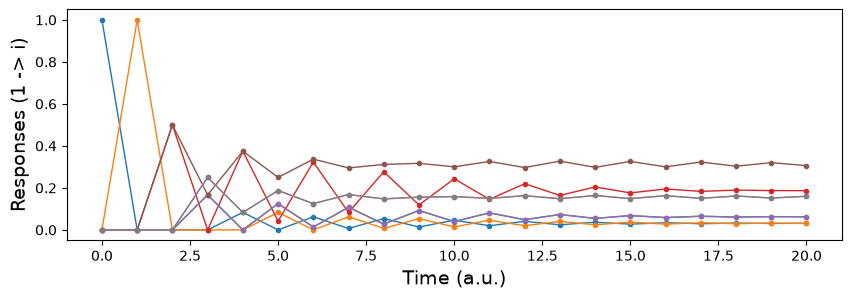

In [14]:
# Plot the pair-wise responses of all nodes, to the initial stimulus on node_0

# Get the x-axis from the 'time' dimension of the response object
tpoints = resp_tensor['time'].values

plt.figure(figsize=(10,3))
# Add the responses from all nodes to input at first node
for i in range(N):
    plt.plot(tpoints, resp_tensor.values[:,i,0], '.-', lw=1) 
plt.xlabel( 'Time (a.u.)' );
plt.ylabel( 'Responses (1 -> i)' );
#plt.tight_layout()

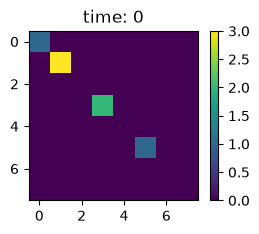

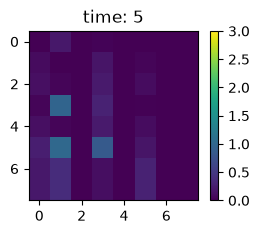

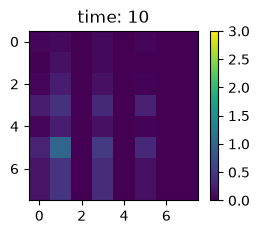

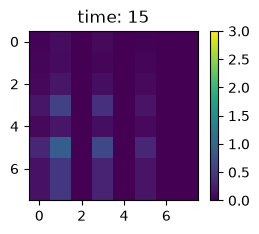

In [15]:
# Plot some response matrices
cmax = resp_tensor.attrs['S0'].max()

for t in range(0,tfinal,5):
    plt.figure(figsize=(3.,2.2))
    plt.title( 'time: %d' %t )
    plt.imshow(resp_tensor.values[t])    
    plt.clim(0,cmax)
    plt.colorbar()

## 3. Extract and visualise various metrics

#### Some global properties

- The **global response** is the sum of all pair-wise responses at each time-point. Optional parameter `selfresp` allows to include or exclude from the sum, the response that each node elicits on itself.
- **Diversity** is the coefficient of variation among the pairs-wise responses, at each time point. (No `selfresp` parameter, but it should have that too.)

Text(0, 0.5, 'Diversity')

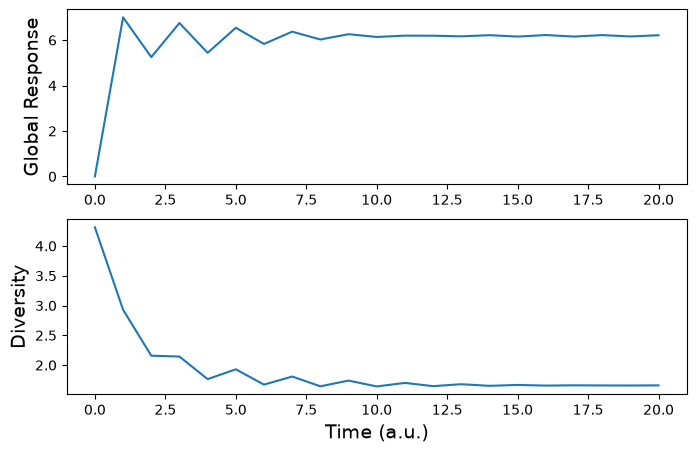

In [16]:
## COMPUTE AND VISUALISE SOME METRICS
globalresp = sna.GlobalResponse(resp_tensor, selfresp=False)
diversity = sna.Diversity(resp_tensor)

# Visualise the results
tpoints = globalresp['time'].values

plt.figure(figsize=(8,5))
plt.subplot(2,1,1)
plt.plot(tpoints, globalresp.values);
plt.ylabel( 'Global Response' )

plt.subplot(2,1,2)
plt.plot(tpoints, diversity.values);
plt.xlabel( 'Time (a.u.)' )
plt.ylabel( 'Diversity' )

The results `globalresp` and `diversity` are new `xarray.DataArray` objects that inherit the 'time' dimension and the attributes from `resp_tensor`, but dropping the two *spatial* dimensions 'nodes_to' and 'nodes_from'.

In [17]:
globalresp
#diversity

<xarray.DataArray (time: 21)> Size: 168B
array([0.        , 7.        , 5.25      , 6.75      , 5.4375    ,
       6.54166667, 5.828125  , 6.36979167, 6.02560764, 6.25868056,
       6.13639323, 6.19505932, 6.19174081, 6.16433377, 6.21508262,
       6.15372495, 6.2209403 , 6.15402159, 6.21826415, 6.15925499,
       6.21226263])
Coordinates:
  * time     (time) uint64 168B 0 1 2 3 4 5 6 7 8 ... 12 13 14 15 16 17 18 19 20
Attributes:
    model:       RandomWalk
    time_class:  discrete
    dt:          1.0
    S0:          [1. 3. 0. 2. 0. 1. 0. 0.]

#### Some node-wise properties

- **Node responses** are the (input) response of each node to all initial perturbations in other nodes, and the influence of the node (output response) to others. Optional parameter `selfresp` is also available to regress out the response of the nodes on themselves (`selfresp = False`) or to conserve it (`selfresp = True`).
- **Self-responses** The response of the nodes due to the stimuli on themselves. It is the component regressed if `selfresp = False` for the node responses.


Text(0, 0.5, 'inputs')

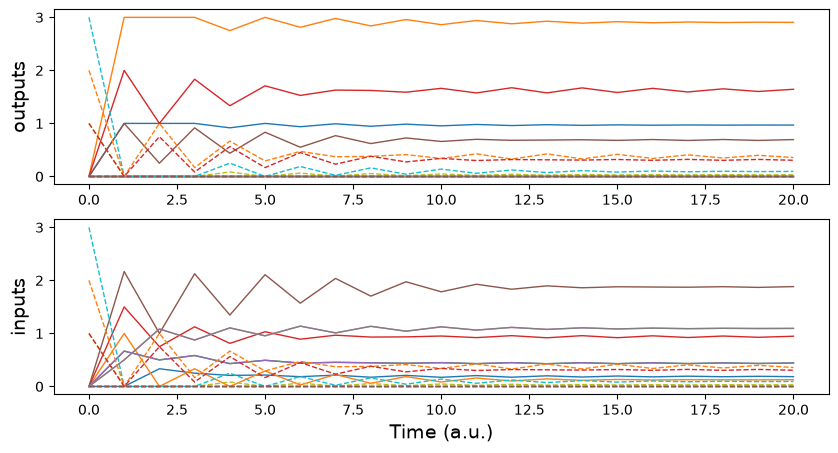

In [18]:
## COMPUTE AND VISUALISE SOME METRICS
inresp, outresp = sna.NodeResponses(resp_tensor, selfresp=False)
selfresp = sna.SelfResponses(resp_tensor)

# Visualise the results
tpoints = selfresp['time'].values

plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(tpoints, outresp.values, lw=1);
plt.plot(tpoints, selfresp.values, '--', lw=1);
plt.ylabel( 'outputs' )

plt.subplot(2,1,2)
plt.plot(tpoints, inresp.values, lw=1);
plt.plot(tpoints, selfresp.values, '--', lw=1);
plt.xlabel( 'Time (a.u.)' )
plt.ylabel( 'inputs' )


Again, `inresp`, `outresp` and `selfresp` are new xarray.DataArray objects, inheriting the 'time' dimension and the corresponding spatial dimension. Notice that `inresp` inherits dimension 'nodes_to' while  `outresp` inherits 'nodes_to'. However, `selfresp` is neither an input nor an output as it is computed from the diagonals of the response matrices $R_{ii}(t)$. Therefore, `selfresp` contains a "new" spatial dimension 'nodes' with the same labels.

All necessary attributes are also passed from `resp_tensor` to the results.

In [19]:
inresp
#outresp
#selfresp

<xarray.DataArray (time: 21, nodes_to: 8)> Size: 1kB
array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 1.        , 0.66666667, 1.5       , 0.66666667,
        2.16666667, 0.5       , 0.5       ],
       [0.33333333, 0.        , 0.5       , 0.75      , 0.5       ,
        1.        , 1.08333333, 1.08333333],
       [0.25      , 0.33333333, 0.58333333, 1.125     , 0.58333333,
        2.125     , 0.875     , 0.875     ],
       [0.20833333, 0.        , 0.43055556, 0.8125    , 0.43055556,
        1.34722222, 1.10416667, 1.10416667],
       [0.21527778, 0.29166667, 0.49305556, 1.03125   , 0.49305556,
        2.10763889, 0.95486111, 0.95486111],
       [0.18402778, 0.02777778, 0.44097222, 0.890625  , 0.44097222,
        1.56944444, 1.13715278, 1.13715278],
       [0.21354167, 0.22569444, 0.45428241, 0.96614583, 0.45428241,
        2.03674769, 1.00954861, 1.00954861],
       [0.17332176, 0.05902778, 0.4458912 , 0.93098958, 0.4458912 ,
        1.70283565, 1.13382523, 1.13382523],
       [0.20905671, 0.18547454, 0.43648727, 0.93424479, 0.43648727,
        1.97345197, 1.041739  , 1.041739  ],
...
       [0.20451148, 0.15878183, 0.42972367, 0.92062717, 0.42972367,
        1.92684823, 1.06242163, 1.06242163],
       [0.17431641, 0.10269579, 0.44877869, 0.9574924 , 0.44877869,
        1.83288122, 1.1133988 , 1.1133988 ],
       [0.2001079 , 0.14201751, 0.42830605, 0.91725893, 0.42830605,
        1.89680437, 1.07576648, 1.07576648],
       [0.17752289, 0.11449894, 0.44734449, 0.95752631, 0.44734449,
        1.86027521, 1.10528514, 1.10528514],
       [0.19630137, 0.13204039, 0.42925774, 0.91892158, 0.42925774,
        1.879521  , 1.08421257, 1.08421257],
       [0.18056648, 0.12148508, 0.44528466, 0.95446796, 0.44528466,
        1.87447132, 1.09969006, 1.09969006],
       [0.19328417, 0.12655439, 0.43102314, 0.92255251, 0.43102314,
        1.87090423, 1.08934001, 1.08934001],
       [0.18302586, 0.1251852 , 0.44320272, 0.95048773, 0.44320272,
        1.88076558, 1.09619718, 1.09619718],
       [0.19106002, 0.12388756, 0.43283971, 0.92649172, 0.43283971,
        1.86760909, 1.09226358, 1.09226358],
       [0.18482732, 0.12682376, 0.44140794, 0.94670561, 0.44140794,
        1.88263339, 1.09422832, 1.09422832]])
Coordinates:
  * time      (time) uint64 168B 0 1 2 3 4 5 6 7 8 ... 13 14 15 16 17 18 19 20
  * nodes_to  (nodes_to) <U6 192B 'node_0' 'node_1' ... 'node_6' 'node_7'
Attributes:
    model:       RandomWalk
    time_class:  discrete
    dt:          1.0
    S0:          [1. 3. 0. 2. 0. 1. 0. 0.]

#### Flexible functions

Some of the metrics in Stimulus-Response Network Analysis can be evaluated on different levels or representations. Such is the case of the *time-to-peak* (generalisation of the graph distance) or the *total response* evaluating the integral or area-under-curve. We illustrate this computing the total response on three cases: 
- pair-wise responses,
- node responses and
- global response.


In [20]:
## COMPUTE THE TOTAL RESPONSES FOR THREE CASES 

# For the pair-wise responses
totalresp_pairwise = sna.AreaUnderCurve(resp_tensor)
# For the node responses
totalresp_nodes = sna.AreaUnderCurve(selfresp)
# For the global response
totalresp_global = sna.AreaUnderCurve(globalresp)


Text(0, 0.5, 'nodes_from')

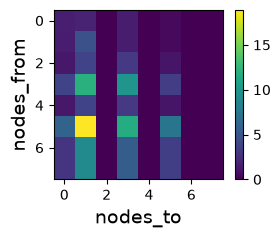

In [21]:
# VISUALISE THE TOTAL PAIR-WISE RESPONSES (AS A 2D MATRIX)

plt.figure(figsize=(3.,2.2))
plt.imshow(totalresp_pairwise.values, vmin=0)
plt.colorbar()
dim0name = totalresp_pairwise.dims[0]
dim1name = totalresp_pairwise.dims[1]
plt.xlabel( dim0name )
plt.ylabel( dim1name )

Notice how `totalresp_pairwise` is a square matrix with the dimensions 'nodes_to' and 'nodes_from' inherited from `resp_tensor` but squeezed over 'time'. 

Also, the calculation of the integral requires knowledge of the original simulation time-step `dt` which, we no longer need to manually pass to function `AreaUnderCurve()`, because it is internally carried in the carried metadata.

In [22]:
totalresp_pairwise

<xarray.DataArray (nodes_to: 8, nodes_from: 8)> Size: 512B
array([[ 1.57332635,  1.81352072,  0.        ,  1.51938143,  0.        ,
         0.51160612,  0.        ,  0.        ],
       [ 1.54173381,  4.71997904,  0.        ,  1.4613762 ,  0.        ,
         0.47832572,  0.        ,  0.        ],
       [ 1.20901381,  3.81389051,  0.        ,  3.17134023,  0.        ,
         1.08283262,  0.        ,  0.        ],
       [ 3.81389051, 12.00826234,  0.        ,  9.87046224,  0.        ,
         3.44176362,  0.        ,  0.        ],
       [ 1.20901381,  3.81389051,  0.        ,  3.17134023,  0.        ,
         1.08283262,  0.        ,  0.        ],
       [ 5.97955576, 18.89178958,  0.        , 11.71476047,  0.        ,
         7.3537825 ,  0.        ,  0.        ],
       [ 2.83673297,  8.96933364,  0.        ,  5.5456696 ,  0.        ,
         3.5244284 ,  0.        ,  0.        ],
       [ 2.83673297,  8.96933364,  0.        ,  5.5456696 ,  0.        ,
         3.5244284 ,  0.        ,  0.        ]])
Coordinates:
  * nodes_to    (nodes_to) <U6 192B 'node_0' 'node_1' ... 'node_6' 'node_7'
  * nodes_from  (nodes_from) <U6 192B 'node_0' 'node_1' ... 'node_6' 'node_7'
Attributes:
    model:       RandomWalk
    time_class:  discrete
    dt:          1.0
    S0:          [1. 3. 0. 2. 0. 1. 0. 0.]

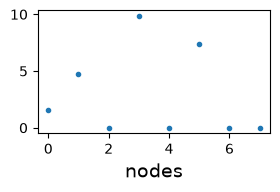

In [23]:
# VISUALISE THE NODE (self) RESPONSES (AS A 1D VECTOR)

plt.figure(figsize=(3.,1.6))
plt.plot(totalresp_nodes.values, '.');
plt.xlabel( totalresp_nodes.dims[0] );

Now, `totalresp_nodes` is 1D obejct (array) with dimension 'nodes' and the 'time' dimension squeezed. However, it still conserves all other attributes inherited from the input `selfresp`.


In [24]:
totalresp_nodes

<xarray.DataArray (nodes: 8)> Size: 64B
array([1.57332635, 4.71997904, 0.        , 9.87046224, 0.        ,
       7.3537825 , 0.        , 0.        ])
Coordinates:
  * nodes    (nodes) <U6 192B 'node_0' 'node_1' 'node_2' ... 'node_6' 'node_7'
Attributes:
    model:       RandomWalk
    time_class:  discrete
    dt:          1.0
    S0:          [1. 3. 0. 2. 0. 1. 0. 0.]

Finally, `totalresp_global` is just an scalar number since it is the area-under-curve of the 1D `globalresp`. It has *DataArray* with no dimensions but still inherits the corresponding attributes:

In [25]:
totalresp_global

<xarray.DataArray ()> Size: 8B
array(123.48244988)
Attributes:
    model:       RandomWalk
    time_class:  discrete
    dt:          1.0
    S0:          [1. 3. 0. 2. 0. 1. 0. 0.]